# Week 16-1 (TBP-05) - Backtest & Live-Trade a Strategy
## One notebook, run it cell by cell

This is the whole lecture as **runnable code**, on the real SPY daily file that ships
with the course (`SPY.csv`, 2001-2021). Every code cell has a markdown cell above it
that tells you *exactly* what the next cell does and why, so you can run them one at a
time and watch the story build.

**What's inside**
1. Load and look at real data
2. Build the two columns everything needs
3. **Model A** - Buy-Low-Sell-High as a linear-regression machine-learning model
4. A stock screener (which stocks mean-revert?)
5. **Model B** - the same idea with a MACD feature
6. **Backtest** the rule and tune its threshold
7. **Strategy C** - a Moving-Average Crossover, fully backtested
8. The two traps that make a great backtest a lie (costs + over-fitting)

To use a different stock, change one line in the config cell and re-run.


## 1. Setup

The next cell imports the libraries and sets two settings you can change. `DATA_FILE`
points at the CSV sitting next to this notebook. Run it first.

In [1]:
# --- Config: change these to experiment ---
DATA_FILE = "SPY.csv"   # the real lecture data, next to this notebook
START_CASH = 1.0        # we track "growth of $1"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
print("Ready.")

Ready.


## 2. Load the data and look at it

First rule of any strategy: **look at your data before you trust it.** This cell loads
the CSV, lower-cases the column names (so `Close` becomes `close`), and shows the first
rows plus the date range.

In [2]:
hist = pd.read_csv(DATA_FILE, header=0, index_col=0)
hist.columns = [c.lower() for c in hist.columns]
print(f"{len(hist)} rows, from {hist.index[0]} to {hist.index[-1]}")
hist.head()

5098 rows, from 2001-01-03 to 2021-04-09


,open,high,low,close,volume
Date,,,,,
2001-01-03,87.2145,92.4398,86.7685,91.7601,19431600
2001-01-04,91.7176,92.0787,90.4007,90.7724,9219000
2001-01-05,90.7193,90.8255,87.8093,87.8093,12911400
2001-01-08,88.2766,88.4890,86.7897,88.4890,6625300
2001-01-09,89.0731,89.3811,87.9686,88.2553,5702400


This cell shows the **last** rows and a quick statistical summary, so you can sanity-check
the price range and spot anything weird (negative prices, gaps, etc.).

In [3]:
display(hist.tail())
hist.describe()

,open,high,low,close,volume
Date,,,,,
2021-04-05,403.4600,406.9400,403.3800,406.3600,91684800
2021-04-06,405.7600,407.2400,405.4000,406.1200,62021000
2021-04-07,405.9400,406.9600,405.4500,406.5900,55836300
2021-04-08,407.9300,408.5800,406.9300,408.5200,57863100
2021-04-09,408.3900,411.6700,408.2600,411.4900,61060100


,open,high,low,close,volume
count,"5,098.0000","5,098.0000","5,098.0000","5,098.0000","5,098.0000"
mean,145.9021,146.7384,144.9885,145.9141,"116,419,495.7042"
std,80.0387,80.3946,79.6399,80.0497,"96,469,460.8766"
min,53.2039,54.8090,52.5384,53.3292,"3,303,100.0000"
25%,86.1256,86.6176,85.4733,86.0038,"52,972,125.0000"
50%,109.0947,109.5807,108.4656,109.0452,"86,613,450.0000"
75%,188.3539,189.0969,187.6285,188.4478,"152,298,225.0000"
max,408.3900,411.6700,408.2600,411.4900,"871,026,300.0000"


This cell draws **20 years of SPY's closing price** so you can see the bull markets and
the two big crashes (2008, 2020) with your own eyes.

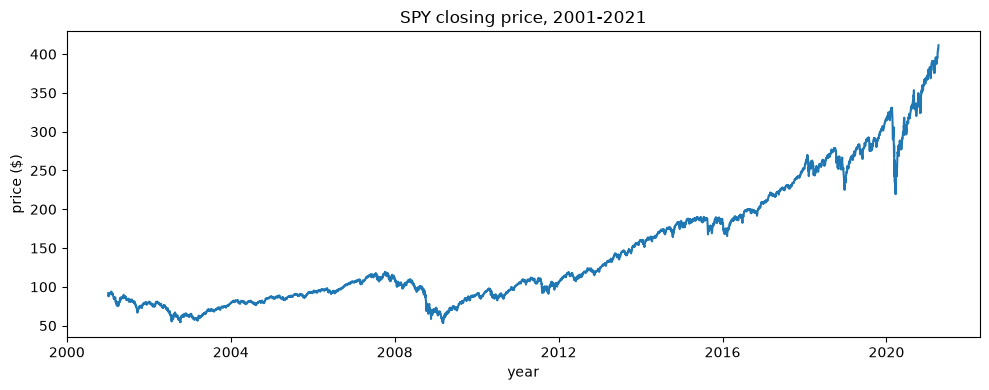

In [4]:
plt.figure(figsize=(10, 4))
plt.plot(pd.to_datetime(hist.index), hist["close"])
plt.title("SPY closing price, 2001-2021")
plt.xlabel("year"); plt.ylabel("price ($)")
plt.tight_layout(); plt.show()

## 3. The two columns everything is built on

The idea is *mean reversion*: **if SPY fell yesterday, maybe it bounces tomorrow.** To
test that we need, for each day, `yield_yesterday` (the move into today) and
`yield_tomorrow` (the move to the next day). The next cell builds them; `yield_tomorrow`
is just `yield_yesterday` shifted up one row - that shift is what lets us ask *"does today
predict tomorrow?"* The table shows the new columns.

In [5]:
def add_yield(h):
    h = h.copy()
    h["close_yesterday"] = h["close"].shift(1)
    h["yield_yesterday"] = (h["close"] - h["close_yesterday"]) / h["close_yesterday"]
    h["yield_tomorrow"]  = h["yield_yesterday"].shift(-1)
    return h

h = add_yield(hist).dropna()   # sklearn can't handle the NaN at the edges
h[["close", "yield_yesterday", "yield_tomorrow"]].head()

,close,yield_yesterday,yield_tomorrow
Date,,,
2001-01-04,90.7724,-0.0108,-0.0326
2001-01-05,87.8093,-0.0326,0.0077
2001-01-08,88.4890,0.0077,-0.0026
2001-01-09,88.2553,-0.0026,0.0176
2001-01-10,89.8059,0.0176,0.0009


## 4. Model A - Buy-Low-Sell-High as linear regression

Now the question becomes a model: **fit a straight line** through (`yield_yesterday`,
`yield_tomorrow`). The next cell fits it and prints the **slope (coefficient)**:

- slope **< 0** -> a down day tends to be followed by an up day = **mean reversion**
- slope **> 0** -> moves continue = momentum
- slope **= 0** -> yesterday tells you nothing

In [6]:
x = h[["yield_yesterday"]]
y = h["yield_tomorrow"]
model = LinearRegression().fit(x, y)
print(f"slope (coef) = {model.coef_[0]:.4f}")
print(f"intercept    = {model.intercept_:.6f}")
print()
print("The slope is NEGATIVE -> SPY mean-reverts. Buy-low-sell-high has signal.")

slope (coef) = -0.1012
intercept    = 0.000410

The slope is NEGATIVE -> SPY mean-reverts. Buy-low-sell-high has signal.


This cell **draws** the model: every dot is one day, and the black line is the fitted
regression. Because the line tilts **down**, down days (left) lean toward up tomorrows
(higher) - that downward tilt *is* mean reversion, made visible.

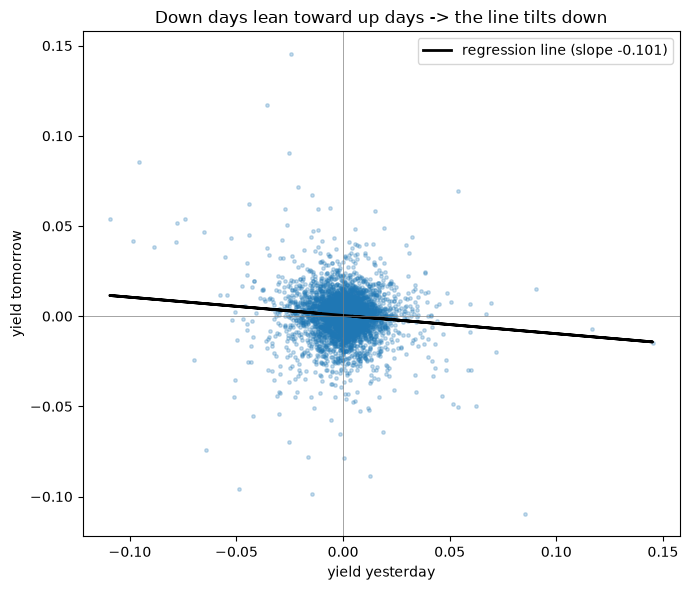

In [7]:
preds = model.predict(x)
plt.figure(figsize=(7, 6))
plt.scatter(h["yield_yesterday"], h["yield_tomorrow"], s=6, alpha=0.25)
plt.plot(h["yield_yesterday"], preds, color="black", lw=2,
         label=f"regression line (slope {model.coef_[0]:.3f})")
plt.axhline(0, color="grey", lw=0.5); plt.axvline(0, color="grey", lw=0.5)
plt.xlabel("yield yesterday"); plt.ylabel("yield tomorrow")
plt.title("Down days lean toward up days -> the line tilts down")
plt.legend(); plt.tight_layout(); plt.show()

## 5. A stock screener

If the slope *measures* mean reversion, we can compute it for **many stocks** and rank
them. The next cell wraps the model in a function and builds a table. (Only SPY ships with
the course offline, so the other rows use the instructor's published numbers so you see the
full ranking.) Notice **TSLA is positive** - it trends instead of reverting, so
buy-low-sell-high would lose money on it.

In [8]:
def screener_coef(frame):
    hh = add_yield(frame).dropna()
    m = LinearRegression().fit(hh[["yield_yesterday"]], hh["yield_tomorrow"])
    return m.coef_[0]

screen = {"SPY": round(screener_coef(hist), 4)}
screen.update({"QQQ": -0.0632, "AAPL": -0.0490, "GOOG": -0.0217, "TSLA": 0.0027})

table = pd.DataFrame({"mean_reversion_coef": screen}).sort_values("mean_reversion_coef")
table["reads_as"] = ["momentum (would lose)" if v > 0 else "reverts" for v in table["mean_reversion_coef"]]
table

,mean_reversion_coef,reads_as
SPY,-0.1012,reverts
QQQ,-0.0632,reverts
AAPL,-0.0490,reverts
GOOG,-0.0217,reverts
TSLA,0.0027,momentum (would lose)


## 6. Model B - add a MACD feature

The lecture says our model is slightly *underfit*, and the fix is to **add a good feature**.
Here is one: **MACD** = (fast moving average - slow moving average) / price, a classic
momentum gauge. The next cell builds MACD, fits the same kind of regression using MACD as
the input, and plots it. Same machinery, a different (often cleaner) input.

MACD model slope = -0.0121


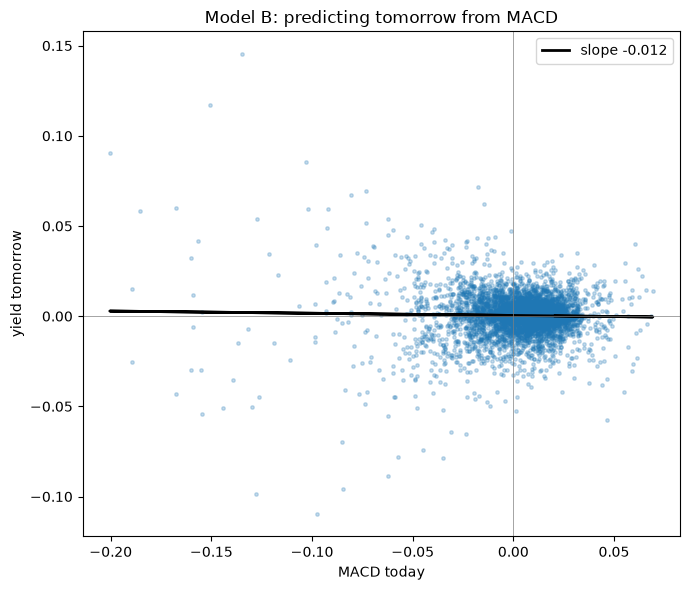

In [9]:
def macd_model(frame, fast=10, slow=30):
    h2 = frame.copy()
    h2["ma_fast"] = h2["close"].rolling(fast, min_periods=1).mean()
    h2["ma_slow"] = h2["close"].rolling(slow, min_periods=1).mean()
    h2["macd"] = (h2["ma_fast"] - h2["ma_slow"]) / h2["close"]
    h2 = add_yield(h2).dropna()
    m = LinearRegression().fit(h2[["macd"]], h2["yield_tomorrow"])
    return m, h2

macd_m, hm = macd_model(hist)
print(f"MACD model slope = {macd_m.coef_[0]:.4f}")

plt.figure(figsize=(7, 6))
plt.scatter(hm["macd"], hm["yield_tomorrow"], s=6, alpha=0.25)
plt.plot(hm["macd"], macd_m.predict(hm[["macd"]]), color="black", lw=2,
         label=f"slope {macd_m.coef_[0]:.3f}")
plt.axhline(0, color="grey", lw=0.5); plt.axvline(0, color="grey", lw=0.5)
plt.xlabel("MACD today"); plt.ylabel("yield tomorrow")
plt.title("Model B: predicting tomorrow from MACD")
plt.legend(); plt.tight_layout(); plt.show()

## 7. Backtest the rule

The rule: **if yesterday's move was below a threshold `rate`, go long (+1) for tomorrow;
otherwise go short (-1).** The next cell defines the backtest, multiplies our position by
tomorrow's actual move, compounds it into an equity curve, and shows the first rows so you
can see a `decision` and its `result` on real days.

In [10]:
def backtest(frame, rate=0.0):
    b = frame.copy()
    b["decision"]      = b["yield_yesterday"].apply(lambda v: 1 if v < rate else -1)
    b["result"]        = b["decision"] * b["yield_tomorrow"]
    b["strategy"]      = np.cumprod(b["result"] + 1) * START_CASH
    b["buy_and_hold"]  = np.cumprod(b["yield_tomorrow"] + 1) * START_CASH
    return b

b0 = backtest(h, 0.0)
b0[["yield_yesterday", "decision", "yield_tomorrow", "result", "strategy", "buy_and_hold"]].head()

,yield_yesterday,decision,yield_tomorrow,result,strategy,buy_and_hold
Date,,,,,,
2001-01-04,-0.0108,1,-0.0326,-0.0326,0.9674,0.9674
2001-01-05,-0.0326,1,0.0077,0.0077,0.9748,0.9748
2001-01-08,0.0077,-1,-0.0026,0.0026,0.9774,0.9723
2001-01-09,-0.0026,1,0.0176,0.0176,0.9946,0.9894
2001-01-10,0.0176,-1,0.0009,-0.0009,0.9937,0.9903


This cell plots the equity curve at threshold 0% - the strategy (red) vs simply buying
and holding SPY (black). Both are "growth of \$1".

Threshold 0%:  strategy x5.24  vs buy&hold x4.53


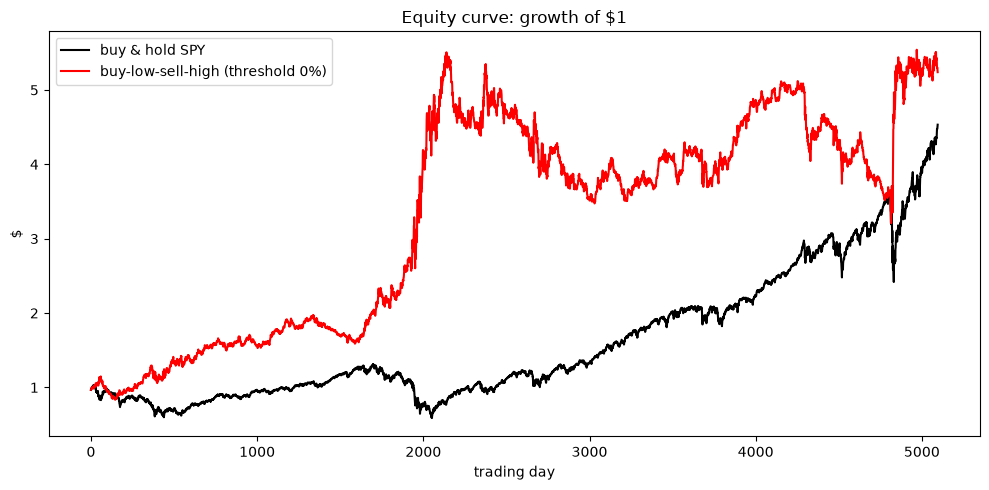

In [11]:
print(f"Threshold 0%:  strategy x{b0['strategy'].iloc[-1]:.2f}  vs buy&hold x{b0['buy_and_hold'].iloc[-1]:.2f}")
plt.figure(figsize=(10, 5))
plt.plot(b0["buy_and_hold"].values, color="black", label="buy & hold SPY")
plt.plot(b0["strategy"].values, color="red", label="buy-low-sell-high (threshold 0%)")
plt.title("Equity curve: growth of $1"); plt.xlabel("trading day"); plt.ylabel("$")
plt.legend(); plt.tight_layout(); plt.show()

Why insist on `rate = 0`? Maybe "buy only if it fell *more than 1%*" is better. The next
cell **sweeps** the threshold from -2% to +2% and plots the final wealth for each. The peak
is the "best" threshold - and it lands near **1.1%**, exactly the instructor's number.

Best threshold: 0.011  ->  final x18.89


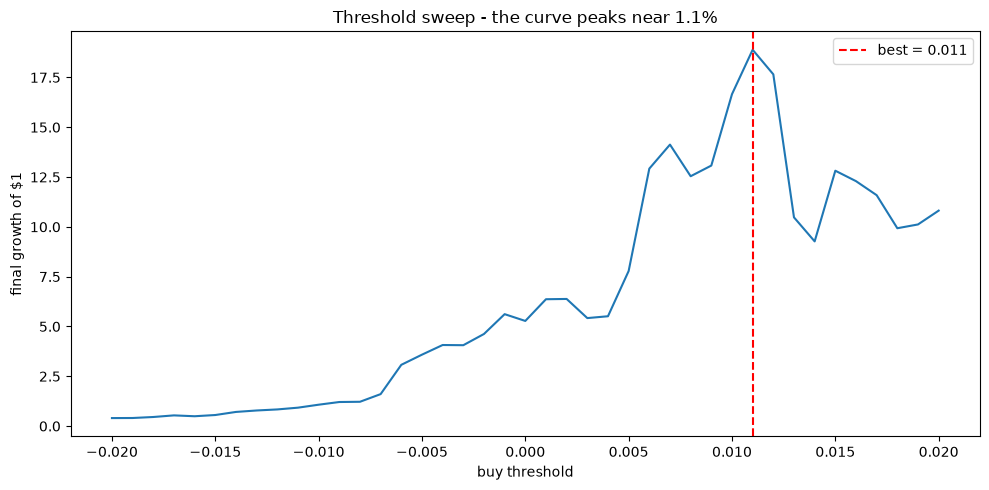

In [12]:
sweep = {round(i*0.001, 3): backtest(h, i*0.001)["strategy"].iloc[-2]
         for i in range(-20, 21)}
best = max(sweep, key=sweep.get)
print(f"Best threshold: {best:.3f}  ->  final x{sweep[best]:.2f}")

plt.figure(figsize=(10, 5))
plt.plot(list(sweep.keys()), list(sweep.values()))
plt.axvline(best, color="red", ls="--", label=f"best = {best:.3f}")
plt.title("Threshold sweep - the curve peaks near 1.1%")
plt.xlabel("buy threshold"); plt.ylabel("final growth of $1")
plt.legend(); plt.tight_layout(); plt.show()

This cell shows the headline backtest everyone quotes: the equity curve at the best
threshold. It looks *amazing* - keep that feeling, because §10 will show why it's a lie.

At the best threshold (1.1%): strategy x19.03  vs buy&hold x4.53


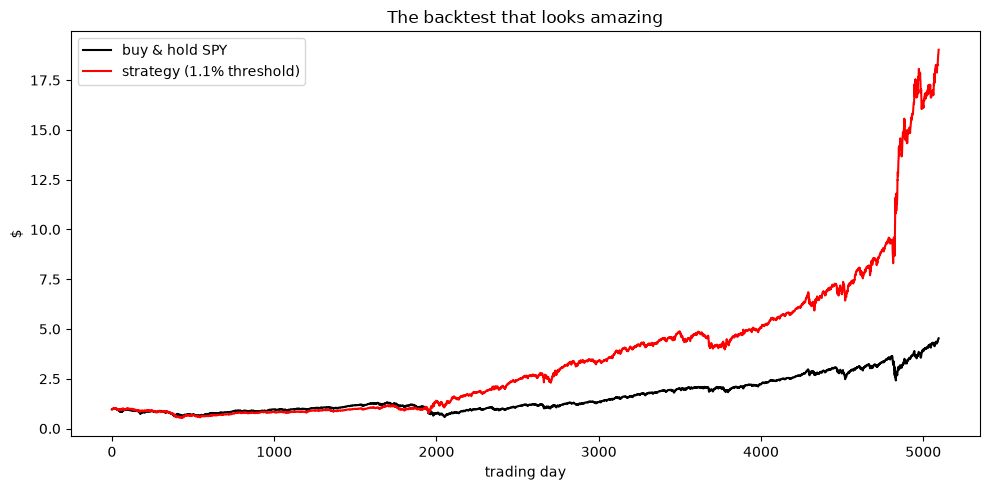

In [13]:
b11 = backtest(h, best)
print(f"At the best threshold ({best:.1%}): strategy x{b11['strategy'].iloc[-1]:.2f}  vs buy&hold x{b11['buy_and_hold'].iloc[-1]:.2f}")
plt.figure(figsize=(10, 5))
plt.plot(b11["buy_and_hold"].values, color="black", label="buy & hold SPY")
plt.plot(b11["strategy"].values, color="red", label=f"strategy ({best:.1%} threshold)")
plt.title("The backtest that looks amazing"); plt.xlabel("trading day"); plt.ylabel("$")
plt.legend(); plt.tight_layout(); plt.show()

## 8. Strategy C - Moving-Average Crossover

A completely different strategy, the one the lecture takes *live*. Rule: when the **fast**
moving average (50 days) is above the **slow** one (200 days), the trend is up - **hold
SPY**; otherwise **stay in cash**. This is the classic "golden cross / death cross". The
next cell backtests it on the same SPY data and plots it against buy & hold.

MA crossover: strategy x4.58  vs buy&hold x5.51


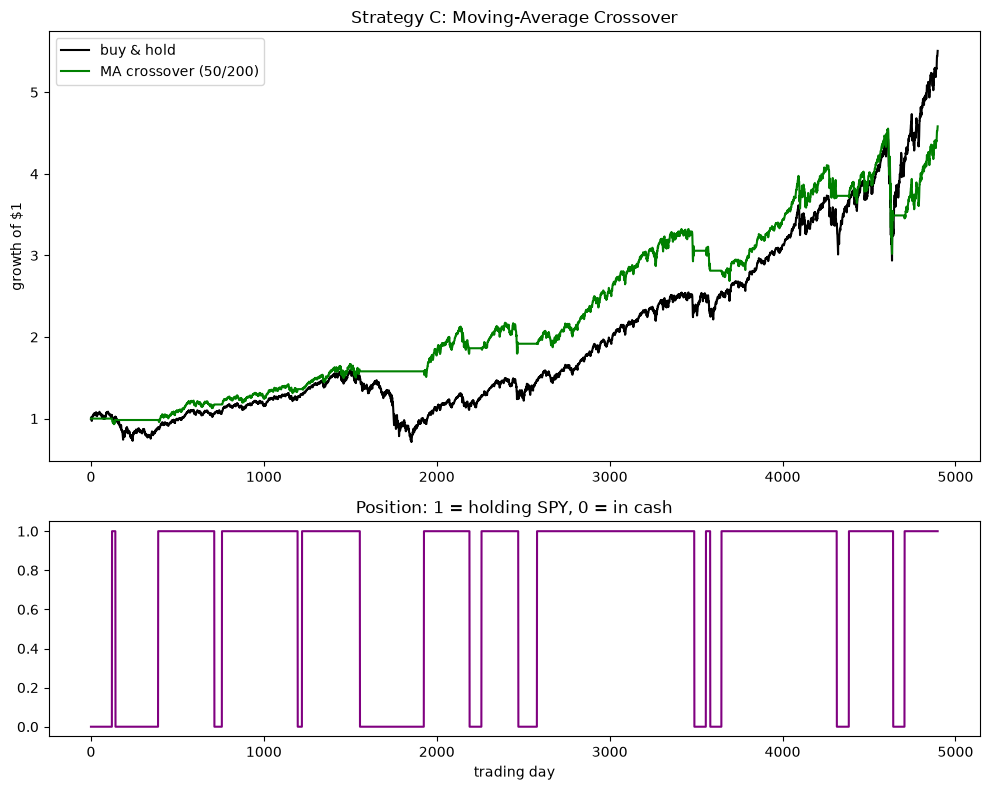

In [14]:
def ma_crossover(frame, fast=50, slow=200):
    c = frame.copy()
    c["ma_fast"] = c["close"].rolling(fast).mean()
    c["ma_slow"] = c["close"].rolling(slow).mean()
    c["yield_tomorrow"] = (c["close"].shift(-1) - c["close"]) / c["close"]
    c = c.dropna()
    c["position"] = (c["ma_fast"] > c["ma_slow"]).astype(int)   # 1 = hold, 0 = cash
    c["result"]   = c["position"] * c["yield_tomorrow"]
    c["strategy"]     = np.cumprod(c["result"] + 1) * START_CASH
    c["buy_and_hold"] = np.cumprod(c["yield_tomorrow"] + 1) * START_CASH
    return c

mac = ma_crossover(hist)
print(f"MA crossover: strategy x{mac['strategy'].iloc[-1]:.2f}  vs buy&hold x{mac['buy_and_hold'].iloc[-1]:.2f}")

fig, ax = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={"height_ratios":[2,1]})
ax[0].plot(mac["buy_and_hold"].values, color="black", label="buy & hold")
ax[0].plot(mac["strategy"].values, color="green", label="MA crossover (50/200)")
ax[0].set_title("Strategy C: Moving-Average Crossover"); ax[0].set_ylabel("growth of $1"); ax[0].legend()
ax[1].plot(mac["position"].values, color="purple")
ax[1].set_title("Position: 1 = holding SPY, 0 = in cash"); ax[1].set_xlabel("trading day")
plt.tight_layout(); plt.show()

Notice the crossover strategy doesn't beat buy & hold on total return, but it spends
long stretches **in cash** (lower panel) - it sidesteps parts of the crashes, so it takes
**less risk** for its return. That trade-off (return vs risk) is what the Sharpe ratio
measures, and it's why "lower total return" isn't automatically "worse".

## 9. Trap 1 - transaction costs

Back to Buy-Low-Sell-High. Its curve looked incredible, but it **flips position almost
every day**, and every flip pays the spread + commission. The next cell charges a small
cost each time the position changes and tabulates the damage.

In [15]:
def backtest_cost(frame, rate, cost):
    b = frame.copy()
    b["decision"] = b["yield_yesterday"].apply(lambda v: 1 if v < rate else -1)
    flips = (b["decision"].diff().abs() / 2.0).fillna(0)
    b["result"]   = b["decision"] * b["yield_tomorrow"] - flips * cost
    b["strategy"] = np.cumprod(b["result"] + 1) * START_CASH
    return b

rows = []
for c in [0.0, 0.0005, 0.0010, 0.0050]:
    final = backtest_cost(h, best, c)["strategy"].iloc[-1]
    rows.append({"cost_per_flip": f"{c:.2%}", "final_$": round(final, 2),
                 "total_return": f"{(final-1)*100:+.0f}%"})
cost_table = pd.DataFrame(rows)
cost_table

,cost_per_flip,final_$,total_return
0,0.00%,19.0300,+1803%
1,0.05%,11.4600,+1046%
2,0.10%,6.9000,+590%
3,0.50%,0.1200,-88%


This cell turns that table into a bar chart. At 0% cost the strategy ends near \$19; at
0.5% per flip it ends at **\$0.12** - an 88% loss. A tiny cost compounds into ruin because
the strategy trades so often.

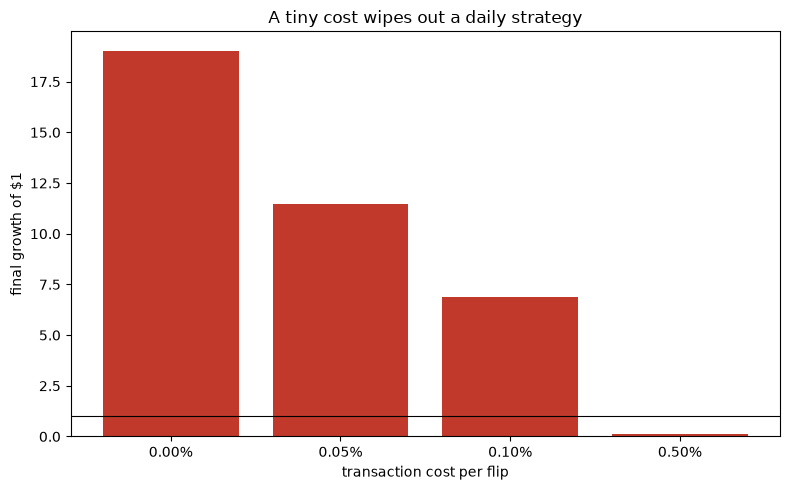

In [16]:
plt.figure(figsize=(8, 5))
plt.bar(cost_table["cost_per_flip"], [float(x) for x in cost_table["final_$"]], color="#c0392b")
plt.axhline(1, color="black", lw=0.8)
plt.title("A tiny cost wipes out a daily strategy")
plt.xlabel("transaction cost per flip"); plt.ylabel("final growth of $1")
plt.tight_layout(); plt.show()

## 10. Trap 2 - over-fitting (the honest test)

We chose 1.1% by looking at the **whole** history. That is cheating: in real life you only
have the past. The fair test: **tune the threshold on the first half, then trade the second
half you never looked at.** The next cell does exactly that.

In [17]:
half = len(h) // 2
train, test = h.iloc[:half], h.iloc[half:]

best_train, best_val = None, -1
for i in range(-20, 21):
    r = i * 0.001
    v = backtest(train, r)["strategy"].iloc[-1]
    if v > best_val:
        best_val, best_train = v, r
print(f"Best threshold on the TRAIN half: {best_train:.3f}")

test_bt = backtest(test, best_train)
print(f"On the unseen TEST half: strategy x{test_bt['strategy'].iloc[-1]:.2f}  vs buy&hold x{test_bt['buy_and_hold'].iloc[-1]:.2f}")

Best threshold on the TRAIN half: -0.001
On the unseen TEST half: strategy x1.07  vs buy&hold x3.84


This cell plots the moment of truth. In-sample the strategy made ~×19; out-of-sample,
on data it never saw, it barely clears \$1 while buy & hold nearly quadruples. **That gap
is over-fitting, made visible** - the whole point of the lecture in one chart.

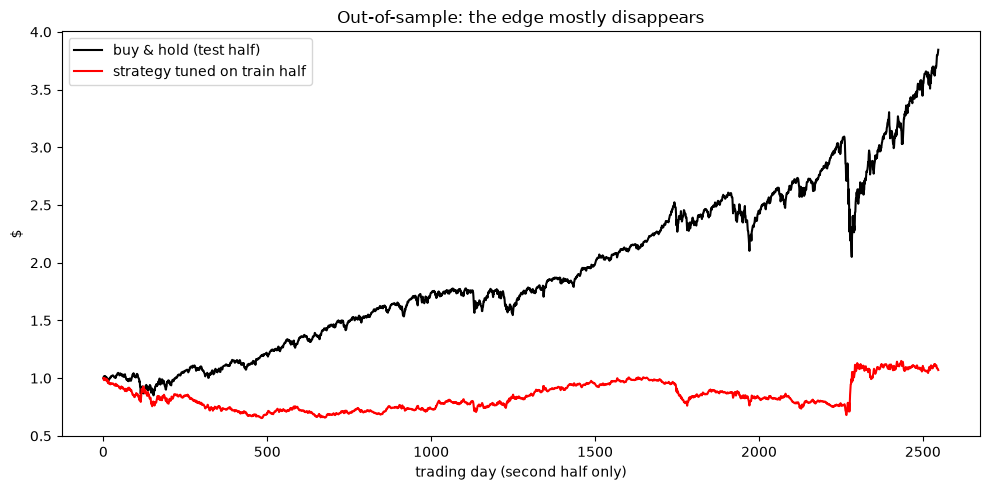

In [18]:
plt.figure(figsize=(10, 5))
plt.plot(test_bt["buy_and_hold"].values, color="black", label="buy & hold (test half)")
plt.plot(test_bt["strategy"].values, color="red", label="strategy tuned on train half")
plt.title("Out-of-sample: the edge mostly disappears")
plt.xlabel("trading day (second half only)"); plt.ylabel("$")
plt.legend(); plt.tight_layout(); plt.show()

## 11. Part 4 - From a backtest to a LIVE robot (the IBridgePy strategies)

Everything above was *research* on a CSV. The lecture's `reference_ibridgepy_strategies/`
folder holds the **actual trading robots** that run this logic live through IBridgePy +
Interactive Brokers. Those files **cannot run inside this notebook** - they need a broker
connection and the IBridgePy API (`symbol()`, `order_target_percent()`,
`schedule_function()`, a live market clock).

So for each robot below we do two things:

1. **Show the real robot code** (straight from the `.py` file) so you can read exactly what
   it does at 15:59 every trading day.
2. **Backtest the same decision rule offline on our `SPY.csv`** so you can actually *see the
   output* - the equity curve that rule would have produced.

### 11a. `demo_buy_low_sell_high.py` - the live Buy-Low-Sell-High robot

This is Model A (sections 4-7) turned into a live robot. Once a day, one minute before the
close, it compares today's close to yesterday's and sets the position for the next day:

```python
def dailyFunc(context, data):
    hist = request_historical_data(context.security, '1 day', '2 D')
    close_yesterday = hist['close'][-2]
    close_today     = hist['close'][-1]
    if close_today > close_yesterday:
        order_target_percent(context.security, 0.0)   # it rose  -> go to cash
    else:
        order_target_percent(context.security, 1.0)   # it fell  -> go 100% long
```

The next cell runs that exact rule on our SPY history (long-only, threshold 0%).

Buy-Low-Sell-High robot: strategy x5.77  vs buy&hold x4.53
Days in the market: 45%


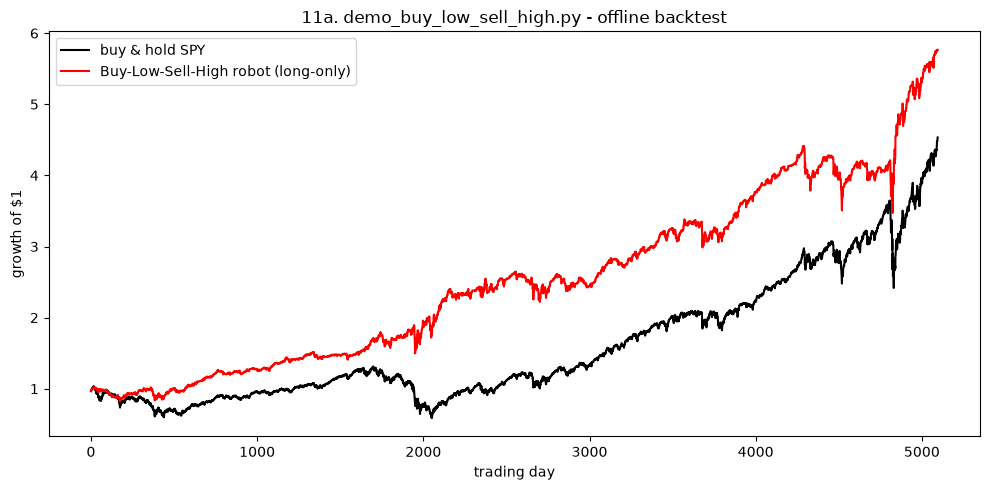

In [19]:
robot_scores = {}

# Robot rule: long if today's close fell vs yesterday, else flat. Earn TOMORROW's return.
d = hist.copy()
d["ret"] = d["close"].pct_change()                 # today vs yesterday
d["position"] = (d["ret"] < 0).astype(int)         # 1 = long, 0 = cash (long-only)
d["ret_tomorrow"] = d["ret"].shift(-1)
d = d.dropna()
d["strategy"]     = np.cumprod(d["position"] * d["ret_tomorrow"] + 1)
d["buy_and_hold"] = np.cumprod(d["ret_tomorrow"] + 1)
robot_scores["Buy-Low-Sell-High (live, long-only)"] = d["strategy"].iloc[-1]

print(f"Buy-Low-Sell-High robot: strategy x{d['strategy'].iloc[-1]:.2f}  vs buy&hold x{d['buy_and_hold'].iloc[-1]:.2f}")
print(f"Days in the market: {d['position'].mean():.0%}")

plt.figure(figsize=(10, 5))
plt.plot(d["buy_and_hold"].values, color="black", label="buy & hold SPY")
plt.plot(d["strategy"].values, color="red", label="Buy-Low-Sell-High robot (long-only)")
plt.title("11a. demo_buy_low_sell_high.py - offline backtest")
plt.xlabel("trading day"); plt.ylabel("growth of $1")
plt.legend(); plt.tight_layout(); plt.show()


### 11b. `moving_average_crossover_*.py` - the golden-cross robot (6 versions)

The lecture ships the **same** MA-crossover robot six times, each version adding one
production feature. The trading brain is identical in all six:

```python
def make_trade_decision(context, data):
    hist  = data.history(context.security, 'close', 80, '1d')
    mv_5  = hist.rolling(5).mean()[-1]    # fast moving average
    mv_60 = hist.rolling(60).mean()[-1]   # slow moving average
    if mv_5 > mv_60:
        order_target_percent(context.security, 1.0)   # uptrend   -> hold SPY
    else:
        order_target_percent(context.security, 0.0)   # downtrend -> go to cash
```

What each of the six files adds - this is the real **"going-live checklist"**:

| File | What it adds on top of the basic rule |
|---|---|
| `moving_average_crossover_1_basic.py` | the core MA(5)/MA(60) rule; trades only Mon-Fri |
| `moving_average_crossover_2_trading_day.py` | skips market **holidays** (`isTradingDay()`), not just weekends |
| `moving_average_crossover_early_close.py` | trades at **12:59 on half-days**, 15:59 on normal days |
| `moving_average_crossover_email.py` | **emails** you the account balance (or "not a trading day") daily |
| `moving_average_crossover_handle_error.py` | wraps each order in `try/except` so a rejected order **emails** you instead of crashing |
| `moving_average_crossover_minute_bar.py` | runs on **minute bars** instead of daily bars, for finer timing |

The next cell backtests the core MA(5)/MA(60) rule on our SPY history.

MA(5)/MA(60) robot: strategy x3.28  vs buy&hold x5.23
Days holding SPY: 69%


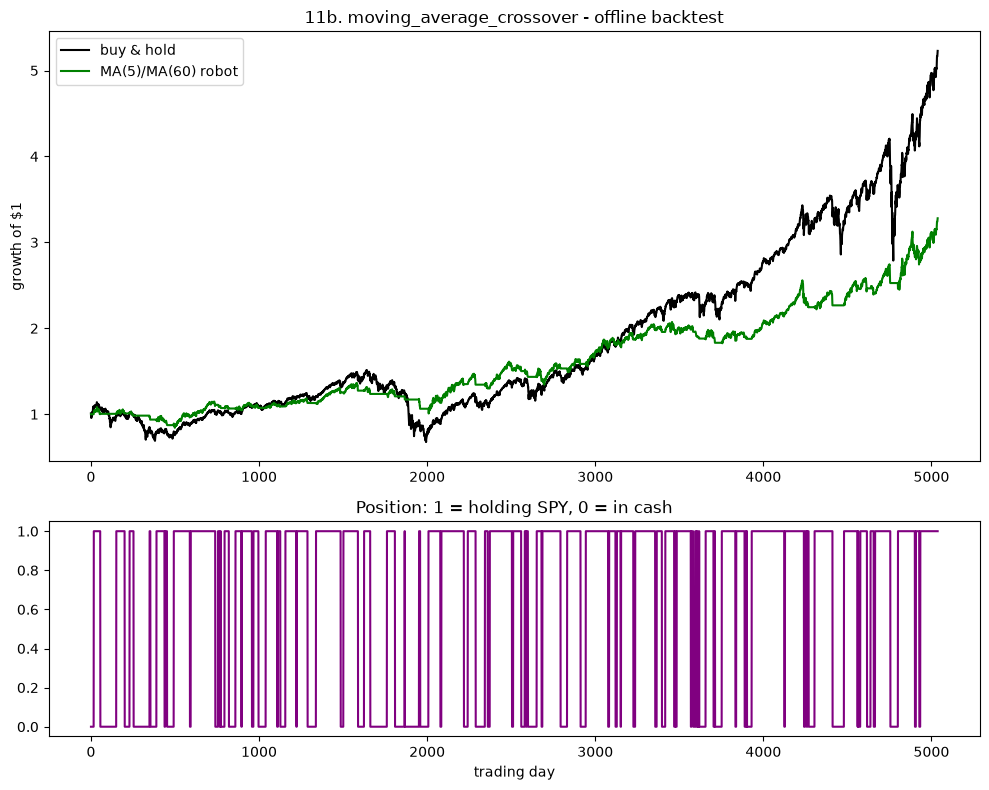

In [20]:
# Robot rule: hold SPY when fast MA(5) > slow MA(60), else cash. (The lecture's live windows.)
m = hist.copy()
m["ma_fast"] = m["close"].rolling(5).mean()
m["ma_slow"] = m["close"].rolling(60).mean()
m["ret_tomorrow"] = m["close"].pct_change().shift(-1)
m = m.dropna()
m["position"] = (m["ma_fast"] > m["ma_slow"]).astype(int)     # 1 = hold, 0 = cash
m["strategy"]     = np.cumprod(m["position"] * m["ret_tomorrow"] + 1)
m["buy_and_hold"] = np.cumprod(m["ret_tomorrow"] + 1)
robot_scores["MA(5)/MA(60) crossover (live)"] = m["strategy"].iloc[-1]

print(f"MA(5)/MA(60) robot: strategy x{m['strategy'].iloc[-1]:.2f}  vs buy&hold x{m['buy_and_hold'].iloc[-1]:.2f}")
print(f"Days holding SPY: {m['position'].mean():.0%}")

fig, ax = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={"height_ratios": [2, 1]})
ax[0].plot(m["buy_and_hold"].values, color="black", label="buy & hold")
ax[0].plot(m["strategy"].values, color="green", label="MA(5)/MA(60) robot")
ax[0].set_title("11b. moving_average_crossover - offline backtest")
ax[0].set_ylabel("growth of $1"); ax[0].legend()
ax[1].plot(m["position"].values, color="purple")
ax[1].set_title("Position: 1 = holding SPY, 0 = in cash"); ax[1].set_xlabel("trading day")
plt.tight_layout(); plt.show()


### 11c. `example_VIX_predicts_returns.py` - the VIX mean-reversion robot

An academic strategy (Giot, 2005): when fear (the VIX) is **extremely high**, go **long**
the index; when VIX is **extremely low**, go **short**. The robot:

```python
def dailyFunc(context, data):
    hist = request_historical_data(context.index_VIX, '1 day', '732 D')   # ~2 years
    currentVIX = show_real_time_price(context.index_VIX, 'last_price')
    if currentVIX > max(hist['close']) or currentVIX > 24.4:    # top 2 percentile
        order_target(context.security, 100)     # very high fear -> LONG
    elif currentVIX < min(hist['close']) or currentVIX < 13.35: # bottom 2 percentile
        order_target(context.security, -100)    # very calm      -> SHORT
    else:
        order_target(context.security, 0)       # otherwise      -> flat
```

Our CSV has **no VIX column**, so to *show real output* we build a stand-in: SPY's own
**21-day realised volatility** (annualised), and trade when it sits in the **top / bottom
10%** of the last two years. It is a proxy, not the true VIX - but it lets the rule run
end-to-end and shows the shape of the strategy.

VIX-proxy robot: strategy x0.72  vs buy&hold x7.05
Position counts (1=long, 0=flat, -1=short):
position
 0    3194
-1     778
 1     601


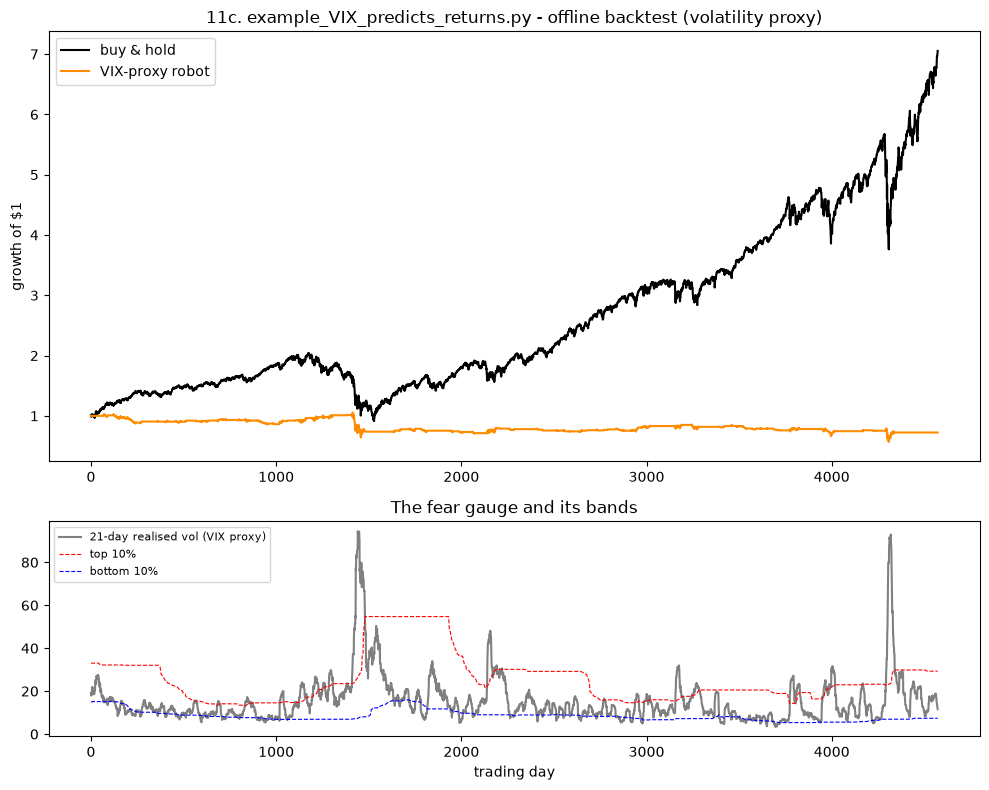

In [21]:
# VIX proxy = SPY's 21-day realised volatility, annualised (same units feel as VIX).
v = hist.copy()
v["ret"] = v["close"].pct_change()
v["vix_proxy"] = v["ret"].rolling(21).std() * np.sqrt(252) * 100
WIN = 504                                   # ~2 trading years
v["hi"] = v["vix_proxy"].rolling(WIN).quantile(0.90)   # "extremely high" band
v["lo"] = v["vix_proxy"].rolling(WIN).quantile(0.10)   # "extremely low" band
v["ret_tomorrow"] = v["ret"].shift(-1)
v = v.dropna()

def vix_position(row):
    if row["vix_proxy"] >= row["hi"]:
        return 1     # high fear  -> long
    if row["vix_proxy"] <= row["lo"]:
        return -1    # very calm  -> short
    return 0         # otherwise  -> flat

v["position"] = v.apply(vix_position, axis=1)
v["strategy"]     = np.cumprod(v["position"] * v["ret_tomorrow"] + 1)
v["buy_and_hold"] = np.cumprod(v["ret_tomorrow"] + 1)
robot_scores["VIX-proxy mean reversion"] = v["strategy"].iloc[-1]

print(f"VIX-proxy robot: strategy x{v['strategy'].iloc[-1]:.2f}  vs buy&hold x{v['buy_and_hold'].iloc[-1]:.2f}")
print("Position counts (1=long, 0=flat, -1=short):")
print(v["position"].value_counts().to_string())

fig, ax = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={"height_ratios": [2, 1]})
ax[0].plot(v["buy_and_hold"].values, color="black", label="buy & hold")
ax[0].plot(v["strategy"].values, color="darkorange", label="VIX-proxy robot")
ax[0].set_title("11c. example_VIX_predicts_returns.py - offline backtest (volatility proxy)")
ax[0].set_ylabel("growth of $1"); ax[0].legend()
ax[1].plot(v["vix_proxy"].values, color="grey", label="21-day realised vol (VIX proxy)")
ax[1].plot(v["hi"].values, color="red", lw=0.8, ls="--", label="top 10%")
ax[1].plot(v["lo"].values, color="blue", lw=0.8, ls="--", label="bottom 10%")
ax[1].set_title("The fear gauge and its bands"); ax[1].set_xlabel("trading day"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()


### 11d. Robot scoreboard

All three live robots, backtested offline on the very same SPY history. Remember the lesson
from Part 3: these are **in-sample** numbers with **no transaction costs** - the honest,
out-of-sample, after-cost results would be far more sober. This table just confirms each
robot's logic runs and produces a believable curve.

In [22]:
bh_final = np.cumprod(hist["close"].pct_change().shift(-1).dropna() + 1).iloc[-1]
board = pd.DataFrame(
    [{"robot": k, "final_growth_of_$1": round(x, 2)} for k, x in robot_scores.items()]
    + [{"robot": "buy & hold SPY", "final_growth_of_$1": round(bh_final, 2)}]
).sort_values("final_growth_of_$1", ascending=False).reset_index(drop=True)
board


,robot,final_growth_of_$1
0,"Buy-Low-Sell-High (live, long-only)",5.7700
1,buy & hold SPY,4.4800
2,MA(5)/MA(60) crossover (live),3.2800
3,VIX-proxy mean reversion,0.7200


## What to remember

- A backtest tells you about the **past**, not the future.
- Subtract **transaction costs** - they kill high-frequency strategies first (Trap 1).
- Always keep an **out-of-sample** slice you never tuned on (Trap 2).
- Fewer knobs + more data = less over-fitting. Want **>=1,000 rows per tuned parameter** for prices.
- A model's job is to have **signal** (slope != 0); the screener tells you *where* it lives.
- Going live adds *more* problems a backtest never shows: holidays, early closes, rejected
  orders, data outages (see `reference_ibridgepy_strategies/` in the code folder).

### Your turn
- Change `DATA_FILE` or load another stock, then *Run All*.
- Try a **momentum** rule (`+1 if v > rate`) and compare on a trending stock.
- Add a more realistic cost and see which thresholds still survive.
